In [3]:
%load_ext autoreload
%autoreload 2

In [ ]:
from src.data.datasets import CommunitySmall

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<int, std::allocator<int> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<double, std::allocator<double> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >, std::allocator<std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<unsigned long, std::allocator<unsigned long> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<double, std::allocator<double> >, std::allocator<s

In [4]:
dataset = CommunitySmall()

/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/torch_geometric/io/fs.py:229: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([SparseGraph])` to allowlist this global.
  warnings.warn(f"{warn_msg} Please use "


In [5]:
g = dataset[0]

In [6]:
from src.data.dataloader import DataLoader

dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

In [7]:
g_b = next(iter(dataloader))
print(g_b)

SparseGraphBatch(x=[34], edge_index=[2, 172], edge_attr=[172], batch=[34], ptr=[3])


In [8]:
import torch
g_b.node_pos = torch.randn(g_b.num_nodes, 2)

In [9]:
g_b = g_b.to_onehot(1, 1)

In [10]:
from src.datatypes.dense import sparse_graph_to_dense_graph

g_dense = sparse_graph_to_dense_graph(g_b, handle_one_hot=True)

In [11]:
g_dense.edge_dist = torch.cdist(g_dense.node_pos, g_dense.node_pos)

In [12]:
from src.noise.graph_diffusion import UniformGraphDiffusionProcess
from src.noise.graph_cont_diffusion import DistanceGaussianDiffusionProcess
from src.noise.schedules import CosineDiffusionSchedule

schedule = CosineDiffusionSchedule(200)
diffusion = UniformGraphDiffusionProcess(schedule, num_cls_x=1, num_cls_e=2, undirected=True)
dist_diff = DistanceGaussianDiffusionProcess(schedule, undirected=True)

In [23]:
noisy = diffusion.sample_from_original(g_dense, torch.tensor([100, 150]))

In [24]:
noisy = dist_diff.sample_from_original(noisy, torch.tensor([1, 150]))

In [25]:
noisy.edge_dist[..., :5, :5] - g_dense.edge_dist[..., :5, :5]

tensor([[[ 0.0000e+00,  2.7744e-02, -5.7337e-03,  7.6543e-03, -5.9588e-03],
         [ 2.7744e-02,  0.0000e+00,  2.2162e-02, -1.0605e-02,  1.7216e-02],
         [-5.7337e-03,  2.2162e-02,  0.0000e+00, -1.0200e-03, -1.1889e-02],
         [ 7.6543e-03, -1.0605e-02, -1.0200e-03,  0.0000e+00, -1.8501e-03],
         [-5.9588e-03,  1.7216e-02, -1.1889e-02, -1.8501e-03,  0.0000e+00]],

        [[ 0.0000e+00, -2.5070e+00, -2.2452e+00,  4.2508e-01, -2.9063e+00],
         [-2.5070e+00,  0.0000e+00,  2.7332e-03, -2.4314e+00, -1.7334e+00],
         [-2.2452e+00,  2.7332e-03,  0.0000e+00, -1.9355e+00, -1.0453e+00],
         [ 4.2508e-01, -2.4314e+00, -1.9355e+00,  0.0000e+00,  1.2911e+00],
         [-2.9063e+00, -1.7334e+00, -1.0453e+00,  1.2911e+00,  0.0000e+00]]])

In [16]:
noisy.edge_adjmat.argmax(dim=-1, keepdim=True).squeeze(-1)

tensor([[[0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
         [1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
         [1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
         [0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
         [1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
         [0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
         [1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
         [1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
         [0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
      

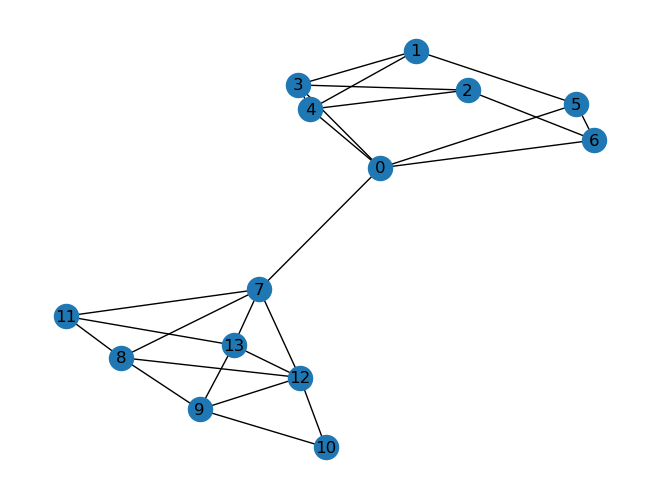

In [9]:
from torch_geometric.utils import to_networkx
import networkx as nx

G = to_networkx(dataset[0], to_undirected=True)
nx.draw(G, with_labels=True)

In [67]:
import torch

dims = 2

node_pos = torch.randn(2, 6, dims)
node_mask = torch.ones(2, 6, dtype=torch.bool)
node_mask[0, -2:] = False  # Masking last two nodes in the first graph
node_pos = node_pos * node_mask.unsqueeze(-1)  # Apply mask to node positions
edge_mask = node_mask.unsqueeze(-1) & node_mask.unsqueeze(-2)

edge_dist = torch.cdist(node_pos, node_pos)
edge_dist.masked_fill_(~edge_mask, 0)
print(edge_dist)

tensor([[[0.0000, 1.2199, 0.9135, 1.7365, 0.0000, 0.0000],
         [1.2199, 0.0000, 0.9953, 2.5938, 0.0000, 0.0000],
         [0.9135, 0.9953, 0.0000, 1.6371, 0.0000, 0.0000],
         [1.7365, 2.5938, 1.6371, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]],

        [[0.0000, 3.1738, 4.0220, 3.8199, 2.4459, 2.5288],
         [3.1738, 0.0000, 0.9126, 2.5181, 0.7386, 2.9344],
         [4.0220, 0.9126, 0.0000, 3.0893, 1.5837, 3.7852],
         [3.8199, 2.5181, 3.0893, 0.0000, 2.6490, 1.6753],
         [2.4459, 0.7386, 1.5837, 2.6490, 0.0000, 2.6102],
         [2.5288, 2.9344, 3.7852, 1.6753, 2.6102, 0.0000]]])


In [ ]:
from models.d4.geometry import mds

updated_node_pos = mds(edge_dist.float(), edge_mask=edge_mask, n_components=dims)
updated_dist = torch.cdist(updated_node_pos, updated_node_pos)

In [84]:
display(node_pos)
display(updated_node_pos)

tensor([[[-0.3130, -0.3859],
         [-1.0822, -1.3328],
         [-1.2258, -0.3479],
         [-0.8854,  1.2535],
         [-0.0000, -0.0000],
         [-0.0000, -0.0000]],

        [[ 2.2872,  2.0057],
         [-0.5735,  0.6311],
         [-1.4859,  0.6126],
         [ 0.7687, -1.4994],
         [ 0.0372,  1.0465],
         [ 2.1265, -0.5180]]])

tensor([[[-0.1508,  0.5729],
         [-1.1392, -0.1421],
         [-0.1639, -0.3405],
         [ 1.4540, -0.0903],
         [-0.0000,  0.0000],
         [-0.0000,  0.0000]],

        [[-1.7155,  1.6733],
         [ 1.1066,  0.2213],
         [ 2.0182,  0.1779],
         [-0.2932, -1.8719],
         [ 0.5075,  0.6532],
         [-1.6237, -0.8538]]])

In [70]:
edge_dist / updated_dist

tensor([[[   nan, 1.0000, 1.0000, 1.0000, 0.0000, 0.0000],
         [1.0000,    nan, 1.0000, 1.0000, 0.0000, 0.0000],
         [1.0000, 1.0000,    nan, 1.0000, 0.0000, 0.0000],
         [1.0000, 1.0000, 1.0000,    nan, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000,    nan,    nan],
         [0.0000, 0.0000, 0.0000, 0.0000,    nan,    nan]],

        [[   nan, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000,    nan, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000,    nan, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,    nan, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000,    nan, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000,    nan]]])

In [163]:
def batch_closed_form_map(A: torch.Tensor,
                          B: torch.Tensor,
                          mask: torch.Tensor,
                          eps: float = 1e-6):
    """
    Closed-form linear map M[b] = (A^T A + eps I)^(-1) A^T B,
    ignoring padded rows (mask==0), all batched with @.
    
    Args:
        A, B : (B, N, p) embeddings
        mask : (B, N) with 1 for real points, 0 for padding
        eps  : float, ridge for numerical stability
        
    Returns:
        M : (B, p, p) projection matrices
    """
    Bbatch, N, p = A.shape
    
    #A = A - A.mean(dim=1, keepdim=True)  # center A
    
    # add 1 padding
    A = torch.cat([A, torch.ones(Bbatch, N, 1, device=A.device)], dim=-1)  # (B, N, p+1)
    B = torch.cat([B, torch.ones(Bbatch, N, 1, device=B.device)], dim=-1)  # (B, N, p+1)
    p = p + 1
    
    # 1) zero out padded rows
    A_mask = A * mask.unsqueeze(-1)    # (B, N, p)
    B_mask = B * mask.unsqueeze(-1)    # (B, N, p)
    
    # 2) form AtA and AtB via batched @
    A_t = A_mask.transpose(1, 2)       # (B, p, N)
    AtA = A_t @ A_mask                 # (B, p, p)
    AtB = A_t @ B_mask                 # (B, p, p)
    
    # 3) invert (AtA + eps I) and multiply
    I = torch.eye(p, device=A.device).unsqueeze(0)  # (1, p, p)
    AtA_reg = AtA + eps * I
    AtA_inv = torch.linalg.inv(AtA_reg)             # (B, p, p)
    M = AtA_inv @ AtB                               # (B, p, p)
    M = M[..., :-1]
    
    # translation
    T = M[..., -1:, :]  # (B, 1, p)
    M = M[..., :-1, :]  # (B, p, p)
    
    return M, T

In [167]:
# compute projection matrix from one to the other
proj_matrix, translation = batch_closed_form_map(updated_node_pos, node_pos, edge_mask[..., 0], eps=0)
proj_node_pos = (updated_node_pos @ proj_matrix + translation) * edge_mask[..., 0].unsqueeze(-1)

In [170]:
proj_matrix

tensor([[[ 0.0559,  0.9984],
         [ 0.9984, -0.0559]],

        [[-0.9996,  0.0273],
         [ 0.0273,  0.9996]]])

In [168]:
display(node_pos)
display(proj_node_pos)

tensor([[[-0.3130, -0.3859],
         [-1.0822, -1.3328],
         [-1.2258, -0.3479],
         [-0.8854,  1.2535],
         [-0.0000, -0.0000],
         [-0.0000, -0.0000]],

        [[ 2.2872,  2.0057],
         [-0.5735,  0.6311],
         [-1.4859,  0.6126],
         [ 0.7687, -1.4994],
         [ 0.0372,  1.0465],
         [ 2.1265, -0.5180]]])

tensor([[[-0.3130, -0.3859],
         [-1.0822, -1.3328],
         [-1.2258, -0.3479],
         [-0.8854,  1.2535],
         [-0.0000, -0.0000],
         [-0.0000, -0.0000]],

        [[ 2.2872,  2.0057],
         [-0.5735,  0.6311],
         [-1.4859,  0.6126],
         [ 0.7687, -1.4994],
         [ 0.0372,  1.0465],
         [ 2.1265, -0.5180]]])

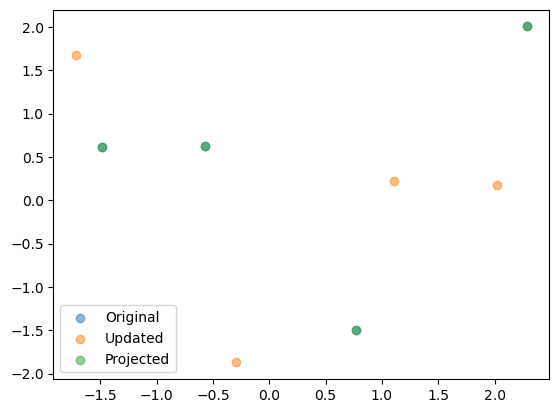

In [171]:
x1 = node_pos[1][node_mask[0]]
x2 = updated_node_pos[1][node_mask[0]]
x3 = proj_node_pos[1][node_mask[0]]


# display coordinates
import matplotlib.pyplot as plt
plt.scatter(x1[:, 0].cpu(), x1[:, 1].cpu(), label='Original', alpha=0.5)
plt.scatter(x2[:, 0].cpu(), x2[:, 1].cpu(), label='Updated', alpha=0.5)
plt.scatter(x3[:, 0].cpu(), x3[:, 1].cpu(), label='Projected', alpha=0.5)
plt.legend()
plt.show()

In [96]:
proj_matrix.shape

torch.Size([2, 2, 2])

In [97]:
updated_dist = torch.cdist(updated_node_pos, updated_node_pos)
updated_dist / edge_dist

tensor([[[   nan, 1.0000, 1.0000, 1.0000,    inf,    inf],
         [1.0000,    nan, 1.0000, 1.0000,    inf,    inf],
         [1.0000, 1.0000,    nan, 1.0000,    inf,    inf],
         [1.0000, 1.0000, 1.0000,    nan,    inf,    inf],
         [   inf,    inf,    inf,    inf,    nan,    nan],
         [   inf,    inf,    inf,    inf,    nan,    nan]],

        [[   nan, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000,    nan, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000,    nan, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,    nan, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000,    nan, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000,    nan]]])

In [98]:
# turn on gradient on edge_dist
edge_dist[0, 3] += 1
eigvals = torch.linalg.eigvalsh(compute_gramm_matrix(edge_dist))
print("Eigenvalues:", eigvals)

NameError: name 'compute_gramm_matrix' is not defined

In [ ]:
print(node_pos)
positions = mds(edge_dist, n_components=3)
positions = positions - positions[-1]
print(positions)

tensor([[ 0.4091, -1.2730,  1.1027],
        [-0.5567,  1.1306,  0.3701],
        [-0.2383,  0.7633,  0.3011],
        [ 1.7676, -2.2955, -0.6677],
        [-0.5530, -0.6113, -0.2712],
        [ 0.4298, -1.2365,  2.1042],
        [ 1.5313,  0.3324,  0.0911],
        [ 0.3948,  1.1960, -0.7962],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000]])
tensor([[-1.5298e+00,  7.8139e-01, -2.2961e-01],
        [ 1.1545e+00,  5.7893e-01, -2.3901e-01],
        [ 7.1376e-01,  3.6877e-01, -2.9080e-01],
        [-2.6158e+00, -1.4123e+00, -4.6898e-02],
        [-2.6843e-01,  4.0250e-02,  8.2424e-01],
        [-1.7144e+00,  1.6458e+00, -7.0233e-01],
        [-3.3346e-01, -6.6964e-01, -1.3798e+00],
        [ 1.0763e+00, -9.0367e-01, -4.9530e-01],
        [ 5.9605e-08, -1.4901e-08,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00]])


In [ ]:
torch.cdist(positions, positions) / edge_dist

tensor([[   nan, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000],
        [1.0000,    nan, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000],
        [1.0000, 1.0000,    nan, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000],
        [1.0000, 1.0000, 1.0000,    nan, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000,    nan, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000,    nan, 1.0000, 1.0000, 1.0000,
         1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,    nan, 1.0000, 1.0000,
         1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,    nan, 1.0000,
         1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,    nan,
            inf],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,    inf,
            nan]])